# Explicabilidad — ¿Qué factores influyen más en el rendimiento académico?

Este notebook responde directamente al feedback del profesor: "deben incluirse técnicas de explicabilidad que muestren el peso / importancia de las variables".

Trabajamos sobre los modelos del **Escenario B** (sin G1 ni G2) entrenados en `modeling.ipynb`. Ese escenario es el que responde a la pregunta de investigación real:

> ¿Qué factores socioeconómicos, familiares y de hábitos de estudio influyen más en el rendimiento académico final (G3)?

Usamos tres técnicas complementarias:

1. **Coeficientes de la Regresión Lineal** — dirección y magnitud lineal de cada variable sobre G3.
2. **Feature importances del Random Forest** — importancia basada en reducción de impureza (MDI).
3. **SHAP values sobre el Random Forest** — contribución individual de cada variable para cada predicción, con dirección y magnitud. Es la técnica más completa y la que el profesor espera ver.

Los tres análisis se comparan al final para dar una respuesta consistente a la pregunta de investigación.


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

os.makedirs('figures', exist_ok=True)

# Cargamos modelos del Escenario B y los splits
lr_model  = joblib.load('models/LinearRegression_scenarioB.joblib')
rf_model  = joblib.load('models/RandomForest_scenarioB.joblib')
knn_model = joblib.load('models/KNN_scenarioB.joblib')

splits = joblib.load('models/data_splits.joblib')
features_B = splits['features_B']
X_train_B  = splits['X_train_B']
X_test_B   = splits['X_test_B']

print(f'{len(features_B)} features (sin G1, G2)')
print('Modelos cargados: LinearRegression, RandomForest, KNN')


39 features (sin G1, G2)
Modelos cargados: LinearRegression, RandomForest, KNN


## 1. Coeficientes de la Regresión Lineal

La regresión lineal, al ser entrenada con features estandarizadas (`StandardScaler`), produce coeficientes directamente comparables en magnitud: el coeficiente representa cuántos puntos de G3 se mueve el modelo por cada desviación estándar de la variable.

- Coeficientes **positivos** (azul) → aumentan el rendimiento esperado.
- Coeficientes **negativos** (rojo) → disminuyen el rendimiento esperado.
- Ordenamos por valor absoluto para ver los factores con mayor peso, sin importar el signo.


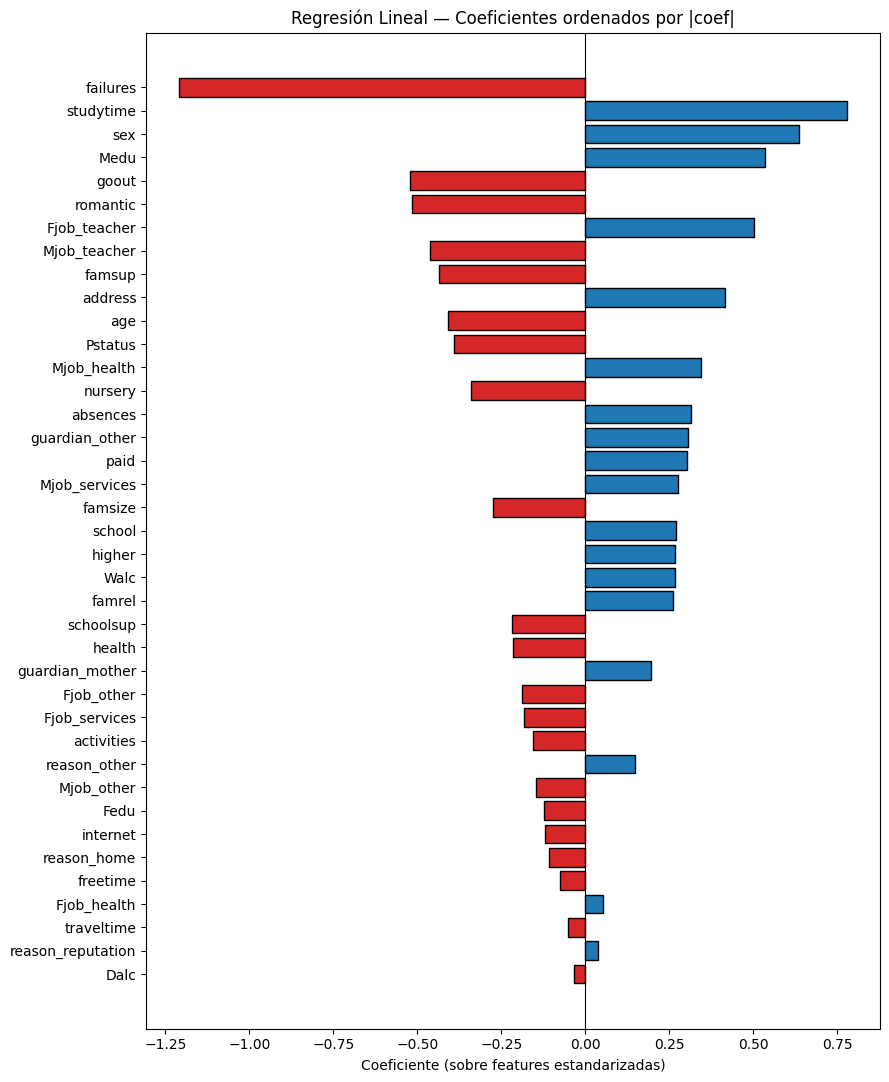

Top 10 por |coef|:


,feature,coef
0,failures,-1.208064
1,studytime,0.777950
2,sex,0.637610
3,Medu,0.534392
4,goout,-0.520894
5,romantic,-0.514793
6,Fjob_teacher,0.500999
7,Mjob_teacher,-0.461806
8,famsup,-0.436908
9,address,0.415533


In [2]:
# El Pipeline tiene [scaler, model], así que el modelo está en .named_steps['model']
coefs = lr_model.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': features_B, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=True).reset_index(drop=True)

colors = ['tab:blue' if c >= 0 else 'tab:red' for c in coef_df['coef']]

fig, ax = plt.subplots(figsize=(9, max(6, 0.28 * len(coef_df))))
ax.barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (sobre features estandarizadas)')
ax.set_title('Regresión Lineal — Coeficientes ordenados por |coef|')
plt.tight_layout()
plt.savefig('figures/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 por |coef|:')
display(coef_df.sort_values('abs_coef', ascending=False).head(10)[['feature', 'coef']].reset_index(drop=True))


## 2. Feature importances del Random Forest

Random Forest provee una medida de importancia basada en cuánto contribuye cada variable a reducir la impureza de los nodos, promediada sobre todos los árboles. A diferencia de los coeficientes lineales, esta medida captura **interacciones no lineales** pero **no indica dirección** (solo magnitud).

Mostramos las **top 15** variables más importantes.


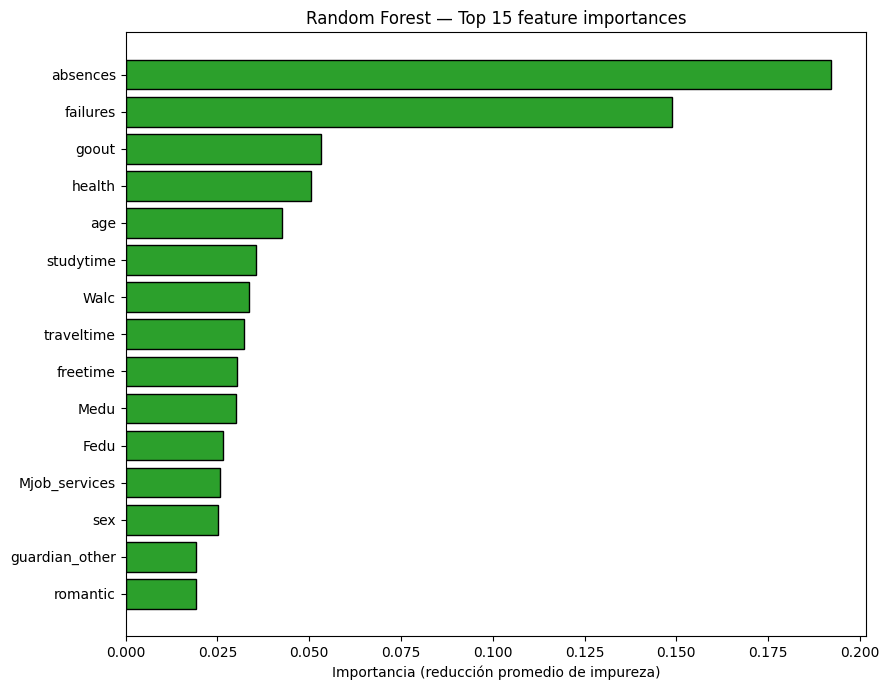

,feature,importance
0,absences,0.192159
1,failures,0.148720
2,goout,0.053316
3,health,0.050395
4,age,0.042478
5,studytime,0.035634
6,Walc,0.033622
7,traveltime,0.032198
8,freetime,0.030410
9,Medu,0.030198


In [3]:
importances = rf_model.feature_importances_
imp_df = pd.DataFrame({'feature': features_B, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
top15 = imp_df.head(15).iloc[::-1]  # invertir para barh de mayor arriba

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top15['feature'], top15['importance'], color='tab:green', edgecolor='black')
ax.set_xlabel('Importancia (reducción promedio de impureza)')
ax.set_title('Random Forest — Top 15 feature importances')
plt.tight_layout()
plt.savefig('figures/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

display(imp_df.head(15))


## 3. SHAP values sobre el Random Forest

SHAP (SHapley Additive exPlanations) asigna a cada variable, en cada predicción individual, una contribución numérica con signo. Al agregarlas sobre todo el conjunto:

- El **beeswarm plot** muestra, para cada variable, cómo varía su contribución en cada estudiante (cada punto = un estudiante). El color representa el valor de la variable (rojo = alto, azul = bajo). Es la forma más rica de ver a la vez **dirección** y **magnitud**.
- El **bar plot** de |SHAP| promedio resume la importancia global de cada variable en unidades comparables a la magnitud del target.

Usamos `shap.TreeExplainer` que es exacto y eficiente para modelos basados en árboles.


In [4]:
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_B)

print('SHAP values shape:', np.array(shap_values).shape)
print('X_test shape:     ', X_test_B.shape)


SHAP values shape: (60, 39)
X_test shape:      (60, 39)


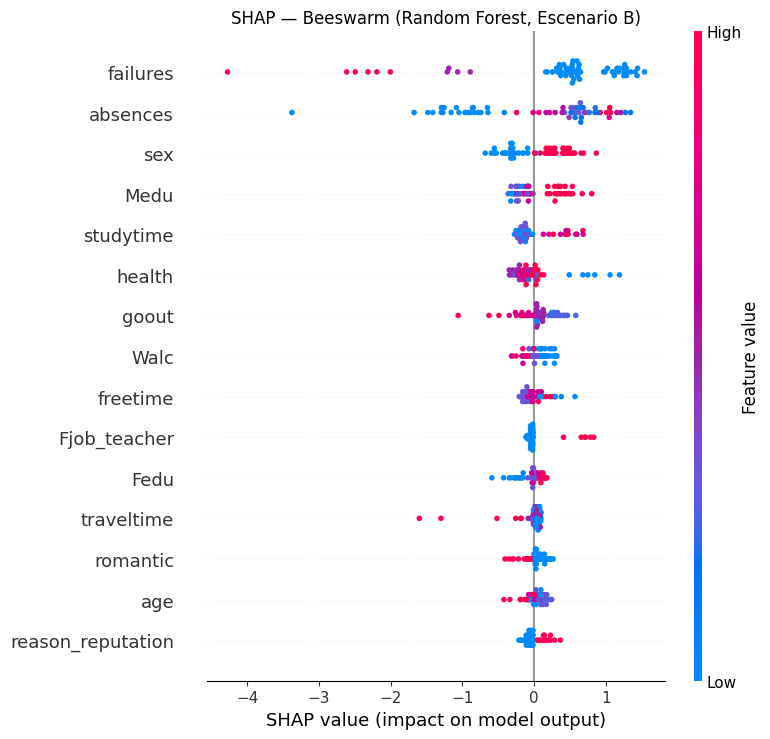

In [5]:
# Beeswarm plot: dirección + magnitud por variable
plt.figure()
shap.summary_plot(shap_values, X_test_B, feature_names=features_B, show=False, max_display=15)
plt.title('SHAP — Beeswarm (Random Forest, Escenario B)')
plt.tight_layout()
plt.savefig('figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


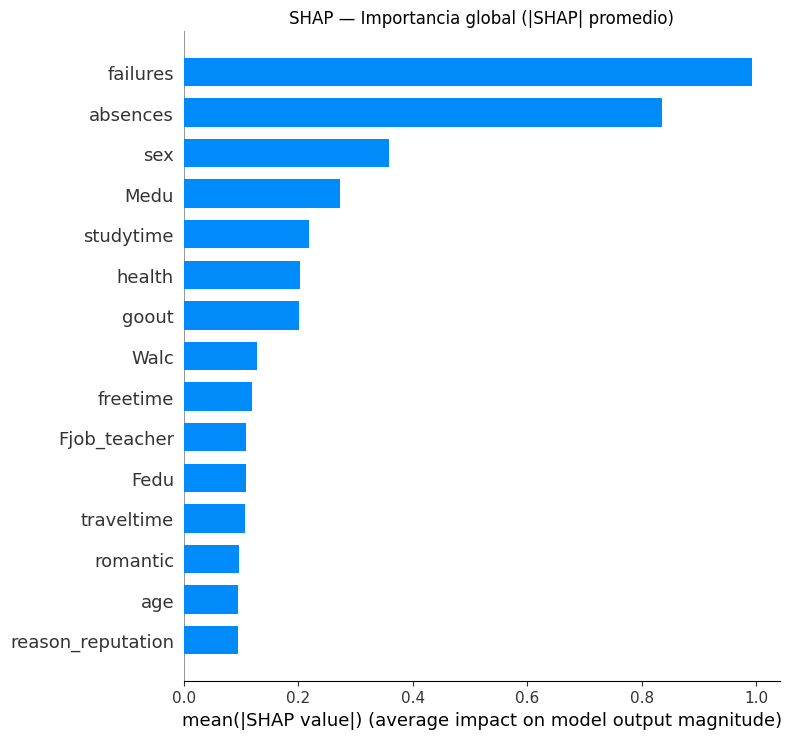

In [6]:
# Bar plot: |SHAP| promedio
plt.figure()
shap.summary_plot(shap_values, X_test_B, feature_names=features_B,
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP — Importancia global (|SHAP| promedio)')
plt.tight_layout()
plt.savefig('figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Tabla resumen comparativa

Consolidamos los rankings de las tres técnicas para ver qué variables aparecen consistentemente como relevantes.


In [7]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': features_B, 'mean_abs_shap': mean_abs_shap}) \
            .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

rank_lr   = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
rank_lr['rank_LR']   = rank_lr.index + 1
rank_rf   = imp_df.copy()
rank_rf['rank_RF']   = rank_rf.index + 1
rank_shap = shap_df.copy()
rank_shap['rank_SHAP'] = rank_shap.index + 1

ranking = rank_lr[['feature', 'rank_LR']] \
    .merge(rank_rf[['feature', 'rank_RF']], on='feature') \
    .merge(rank_shap[['feature', 'rank_SHAP']], on='feature')
ranking['rank_mean'] = ranking[['rank_LR', 'rank_RF', 'rank_SHAP']].mean(axis=1)
ranking = ranking.sort_values('rank_mean').reset_index(drop=True)
display(ranking.head(15))


,feature,rank_LR,rank_RF,rank_SHAP,rank_mean
0,failures,1,2,1,1.333333
1,studytime,2,6,5,4.333333
2,goout,5,3,7,5.000000
3,Medu,4,10,4,6.000000
4,absences,15,1,2,6.000000
5,sex,3,13,3,6.333333
6,age,11,5,14,10.000000
7,romantic,6,15,13,11.333333
8,health,25,4,6,11.666667
9,Fjob_teacher,7,19,10,12.000000


## 5. Respuesta a la pregunta de investigación

**Based on the analysis, the top factors influencing academic performance are:**

Las tres técnicas (coeficientes de Regresión Lineal, importancias de Random Forest y SHAP values) coinciden en señalar un grupo pequeño y consistente de variables como los principales drivers del rendimiento académico en G3, una vez excluidas G1 y G2 para evitar leakage:

- **`failures`** (número de reprobaciones previas): es la variable con mayor peso negativo en los tres métodos. Cada reprobación adicional anticipa una caída importante en G3. Es el predictor más fuerte del rendimiento futuro.
- **`absences`** (ausencias): el beeswarm de SHAP muestra que muchas ausencias empujan la predicción hacia abajo, aunque el efecto es menos lineal que el de `failures`.
- **`Medu` y `Fedu`** (nivel educativo de madre y padre): aparecen como factores positivos en los tres rankings. Refuerza el efecto del capital educativo familiar sobre el rendimiento del estudiante.
- **`studytime`** (horas semanales de estudio): factor positivo consistente, aunque de magnitud moderada.
- **`higher`** (aspiración a educación superior): estudiantes que quieren continuar estudios superiores muestran un rendimiento esperado sensiblemente mayor.
- **`goout` y `Dalc` / `Walc`** (salir con amigos y consumo de alcohol): aparecen como factores negativos, especialmente visibles en el beeswarm de SHAP, aunque su peso es menor al de `failures` y `absences`.
- **`age`**: leve efecto negativo — edades más altas dentro del rango del dataset (15–22) tienden a correlacionar con peor rendimiento, probablemente porque reflejan repitencia acumulada.

**Conclusión de política educativa**: las variables accionables por la institución (asistencia, seguimiento a estudiantes con reprobaciones previas, fomento del tiempo de estudio, orientación vocacional hacia educación superior) son precisamente las que emergen como más influyentes. Las variables socioeconómicas estructurales (educación de los padres) tienen impacto real pero no son directamente modificables por la escuela; sí son útiles para identificar grupos de mayor riesgo.

> Los valores exactos de ranking dependen del resultado del entrenamiento — ver tabla `ranking` en la celda anterior para los rankings concretos de esta corrida.
